# 07 — FT-Transformer (état de l'art tabulaire)

## 🎯 Objectif

Entraîner un **FT-Transformer** (Gorishniy et al., 2021), l'architecture deep state-of-the-art pour données tabulaires, et trancher la question :

> **Le Deep Learning peut-il rivaliser avec XGBoost sur CIC-IDS2017 ?**

## 📋 Plan

1. Setup et imports
2. Chargement + recréation des splits
3. Préparation des données au format pytorch-tabular
4. Configuration du FT-Transformer
5. Entraînement
6. Évaluation sur test
7. **Comparaison finale des 4 modèles** (RF / XGBoost / DNN / FT-Transformer)
8. Sauvegarde

## ⏱️ Temps estimé

**~30 à 60 minutes** sur ta RTX 4050. C'est plus lourd que le DNN à cause de l'attention.

## 1. Setup et imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
from pathlib import Path
from time import time
import warnings
warnings.filterwarnings('ignore')

import torch
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score,
)

from pytorch_tabular import TabularModel
from pytorch_tabular.models import FTTransformerConfig
from pytorch_tabular.config import (
    DataConfig, OptimizerConfig, TrainerConfig, ExperimentConfig
)

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')

DATA_PROCESSED = Path('../data/processed')
RESULTS_FIGURES = Path('../results/figures')
RESULTS_METRICS = Path('../results/metrics')
RESULTS_MODELS = Path('../results/models')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ PyTorch : {torch.__version__}')
print(f'✅ Device  : {DEVICE}')
if DEVICE == 'cuda':
    print(f'✅ GPU     : {torch.cuda.get_device_name(0)}')

W0626 23:29:52.497000 26712 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


✅ PyTorch : 2.11.0+cu128
✅ Device  : cuda
✅ GPU     : NVIDIA GeForce RTX 4050 Laptop GPU


## 2. Chargement et préparation des données

### 📚 Pourquoi pytorch-tabular veut un DataFrame ?

Contrairement à PyTorch "brut" qui veut des tenseurs, pytorch-tabular travaille directement avec des DataFrames pandas. C'est pratique : on garde les noms de colonnes et la lib gère elle-même la normalisation, le batching, etc.

In [2]:
df = pd.read_parquet(DATA_PROCESSED / 'cic-ids-2017_clean.parquet')

with open(DATA_PROCESSED / 'label_mapping.json') as f:
    label_mapping = json.load(f)
label_mapping = {int(k): v for k, v in label_mapping.items()}
class_names = [label_mapping[i] for i in sorted(label_mapping.keys())]
num_classes = len(class_names)

# Pour pytorch-tabular : on garde le label texte, pas l'entier
df_pt = df.drop(columns=['Label_encoded']).copy()
feature_cols = [c for c in df_pt.columns if c != 'Label']
target_col = 'Label'

# Nettoyer les noms de colonnes (pytorch-tabular n'aime pas les espaces)
df_pt.columns = [c.replace(' ', '_').replace('/', '_').replace('.', '_').replace('-', '_') for c in df_pt.columns]
feature_cols = [c.replace(' ', '_').replace('/', '_').replace('.', '_').replace('-', '_') for c in feature_cols]

print(f'📊 Shape : {df_pt.shape}')
print(f'🏷️  Classes : {class_names}')
print(f'🔢 Features : {len(feature_cols)}')

📊 Shape : (2517876, 78)
🏷️  Classes : ['BENIGN', 'Bot', 'Brute Force', 'DDoS', 'DoS', 'PortScan', 'Web Attack']
🔢 Features : 77


In [3]:
# Split identique aux autres notebooks (par index pour respecter le même SEED logique)
# On refait le split sur l'index encodé pour cohérence
y_full = df['Label_encoded'].values

idx = np.arange(len(df_pt))
idx_trainval, idx_test = train_test_split(
    idx, test_size=0.15, stratify=y_full, random_state=SEED
)
idx_train, idx_val = train_test_split(
    idx_trainval, test_size=0.15/0.85,
    stratify=y_full[idx_trainval], random_state=SEED
)

df_train = df_pt.iloc[idx_train].reset_index(drop=True)
df_val = df_pt.iloc[idx_val].reset_index(drop=True)
df_test = df_pt.iloc[idx_test].reset_index(drop=True)

print(f'Train : {len(df_train):>10,}')
print(f'Val   : {len(df_val):>10,}')
print(f'Test  : {len(df_test):>10,}')

Train :  1,762,512
Val   :    377,682
Test  :    377,682


## 3. Configuration du FT-Transformer

### 📚 Les hyperparamètres clés

- `input_embed_dim` : dimension de chaque "token" feature (32 par défaut)
- `num_attn_blocks` : nombre de blocs d'attention empilés (3 = compromis qualité/vitesse)
- `num_heads` : nombre de "têtes" d'attention parallèles (8 = standard Transformer)
- `attn_dropout` / `ff_dropout` : régularisation
- `learning_rate` : 1e-4 (plus bas qu'un MLP, sensible pour les Transformers)

### 📚 Multi-head attention ?

Au lieu d'avoir UN mécanisme d'attention, on en a plusieurs qui regardent les features sous des angles différents. Chacun apprend des relations spécifiques (un peut se concentrer sur les durées, un autre sur les volumes, etc.). Puis on combine.

In [4]:
# Config des données
data_config = DataConfig(
    target=[target_col],
    continuous_cols=feature_cols,
    categorical_cols=[],
    continuous_feature_transform=None,  # Pytorch-tabular fera la normalisation
    normalize_continuous_features=True,
)

# Config du modèle FT-Transformer
model_config = FTTransformerConfig(
    task='classification',
    input_embed_dim=32,
    num_attn_blocks=3,
    num_heads=8,
    attn_dropout=0.1,
    ff_dropout=0.1,
    learning_rate=1e-4,
    metrics=['f1_score', 'accuracy'],
    metrics_params=[{'task': 'multiclass', 'num_classes': num_classes, 'average': 'macro'}, {'task': 'multiclass', 'num_classes': num_classes}],
    metrics_prob_input=[False, False],
)

# Config de l'optimizer
optimizer_config = OptimizerConfig(
    optimizer='Adam',
    lr_scheduler='ReduceLROnPlateau',
    lr_scheduler_params={'mode': 'max', 'factor': 0.5, 'patience': 2},
    lr_scheduler_monitor_metric='valid_f1_score',
)

# Config du trainer
trainer_config = TrainerConfig(
    auto_lr_find=False,
    batch_size=1024,
    max_epochs=30,
    early_stopping='valid_f1_score',
    early_stopping_mode='max',
    early_stopping_patience=5,
    checkpoints='valid_f1_score',
    checkpoints_mode='max',
    load_best=True,
    accelerator='gpu' if DEVICE == 'cuda' else 'cpu',
    progress_bar='simple',
    seed=SEED,
)

print('✅ Configurations créées')
print(f'   - Architecture : FT-Transformer')
print(f'   - Blocs d\'attention : 3')
print(f'   - Têtes d\'attention : 8')
print(f'   - Embedding dim : 32')
print(f'   - Batch size : 1024')
print(f'   - Max epochs : 30 (early stopping patience=5)')

✅ Configurations créées
   - Architecture : FT-Transformer
   - Blocs d'attention : 3
   - Têtes d'attention : 8
   - Embedding dim : 32
   - Batch size : 1024
   - Max epochs : 30 (early stopping patience=5)


## 4. Instanciation et entraînement

On y va. Garde le notebook ouvert pendant ~30-60 min.

In [5]:
# Création du modèle
tabular_model = TabularModel(
    data_config=data_config,
    model_config=model_config,
    optimizer_config=optimizer_config,
    trainer_config=trainer_config,
)

print('🚀 Début de l\'entraînement FT-Transformer...')
print('   (cette étape va prendre 30-60 min selon ton GPU)')
print('   Les barres de progression vont défiler epoch par epoch.\n')

t0 = time()
tabular_model.fit(
    train=df_train,
    validation=df_val,
)
elapsed_train = time() - t0

print(f'\n✅ Entraînement terminé en {elapsed_train/60:.1f} min')

2026-06-26 23:30:03,200 - {pytorch_tabular.tabular_model:145} - INFO - Experiment Tracking is turned off
Seed set to 42


🚀 Début de l'entraînement FT-Transformer...
   (cette étape va prendre 30-60 min selon ton GPU)
   Les barres de progression vont défiler epoch par epoch.



2026-06-26 23:30:03,336 - {pytorch_tabular.tabular_model:547} - INFO - Preparing the DataLoaders
2026-06-26 23:30:04,329 - {pytorch_tabular.tabular_datamodule:527} - INFO - Setting up the datamodule for classification task
2026-06-26 23:30:12,170 - {pytorch_tabular.tabular_model:598} - INFO - Preparing the Model: FTTransformerModel
2026-06-26 23:30:12,376 - {pytorch_tabular.tabular_model:341} - INFO - Preparing the Trainer
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
2026-06-26 23:30:12,585 - {pytorch_tabular.tabular_model:677} - INFO - Training Started
You are using a CUDA device ('NVIDIA GeForce RTX 4050 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium'

┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type                  ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ _backbone        │ FTTransformerBackbone │  135 K │ train │     0 │
│ 1 │ _embedding_layer │ Embedding2dLayer      │  5.1 K │ train │     0 │
│ 2 │ _head            │ LinearHead            │    231 │ train │     0 │
│ 3 │ loss             │ CrossEntropyLoss      │      0 │ train │     0 │
└───┴──────────────────┴───────────────────────┴────────┴───────┴───────┘

Trainable params: 141 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 141 K                                                                                                
Total estimated model params size (MB): 0.565                                                                      
Modules in train mode: 68                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

2026-06-27 01:25:08,736 - {pytorch_tabular.tabular_model:690} - INFO - Training the model completed
2026-06-27 01:25:08,739 - {pytorch_tabular.tabular_model:1531} - INFO - Loading the best model



✅ Entraînement terminé en 115.1 min


## 5. Évaluation sur Test Set

In [7]:
# Re-prédiction (le modèle tabular_model est toujours en mémoire)
from time import time

t0 = time()
predictions = tabular_model.predict(df_test)
ft_inference_time = time() - t0
ft_throughput = len(df_test) / ft_inference_time

print(f'⏱️  Inférence : {ft_inference_time:.2f}s pour {len(df_test):,} échantillons')
print(f'   Débit : {ft_throughput:,.0f} flows/seconde')
print(f'   Colonnes : {list(predictions.columns)}')

# Récupération des prédictions
y_test_pred_ft_label = predictions['Label_prediction'].values
y_test_true_label = df_test['Label'].values

# Conversion en entiers
label_to_int = {v: int(k) for k, v in label_mapping.items()}
y_test_pred_ft = np.array([label_to_int[lbl] for lbl in y_test_pred_ft_label])
y_test_true = np.array([label_to_int[lbl] for lbl in y_test_true_label])

# Métriques
ft_acc = accuracy_score(y_test_true, y_test_pred_ft)
ft_f1_macro = f1_score(y_test_true, y_test_pred_ft, average='macro')
ft_f1_weighted = f1_score(y_test_true, y_test_pred_ft, average='weighted')

print(f'\n📊 FT-TRANSFORMER — Test set')
print(f'   Accuracy     : {ft_acc:.4f}')
print(f'   F1 macro     : {ft_f1_macro:.4f}')
print(f'   F1 pondéré   : {ft_f1_weighted:.4f}')

⏱️  Inférence : 258.78s pour 377,682 échantillons
   Débit : 1,459 flows/seconde
   Colonnes : ['Label_BENIGN_probability', 'Label_Bot_probability', 'Label_Brute Force_probability', 'Label_DDoS_probability', 'Label_DoS_probability', 'Label_PortScan_probability', 'Label_Web Attack_probability', 'Label_prediction']

📊 FT-TRANSFORMER — Test set
   Accuracy     : 0.9946
   F1 macro     : 0.7928
   F1 pondéré   : 0.9941


In [8]:
# Diagnostic : voir ce que contient le DataFrame de prédictions
print("Type :", type(predictions))
print("Colonnes :", list(predictions.columns))
print("\nAperçu des 3 premières lignes :")
predictions.head(3)

Type : <class 'pandas.core.frame.DataFrame'>
Colonnes : ['Label_BENIGN_probability', 'Label_Bot_probability', 'Label_Brute Force_probability', 'Label_DDoS_probability', 'Label_DoS_probability', 'Label_PortScan_probability', 'Label_Web Attack_probability', 'Label_prediction']

Aperçu des 3 premières lignes :


,Label_BENIGN_probability,Label_Bot_probability,Label_Brute Force_probability,Label_DDoS_probability,Label_DoS_probability,Label_PortScan_probability,Label_Web Attack_probability,Label_prediction
0,0.000018,0.000009,0.000021,0.999923,0.000003,0.000017,0.000008,DDoS
1,0.247097,0.000056,0.000276,0.000231,0.749780,0.001915,0.000645,DoS
2,0.000114,0.000004,0.000013,0.000028,0.999766,0.000044,0.000033,DoS


In [10]:
print('📋 FT-Transformer — Rapport par classe (test) :\n')
ft_test_report = classification_report(
    y_test_true, y_test_pred_ft,
    target_names=class_names, digits=4,
)
print(ft_test_report)

ft_test_report_dict = classification_report(
    y_test_true, y_test_pred_ft,
    target_names=class_names, output_dict=True,
)
with open(RESULTS_METRICS / 'ft_test_report.json', 'w') as f:
    json.dump(ft_test_report_dict, f, indent=2)
print('💾 Rapport sauvegardé')

📋 FT-Transformer — Rapport par classe (test) :

              precision    recall  f1-score   support

      BENIGN     0.9952    0.9983    0.9968    313856
         Bot     1.0000    0.3699    0.5400       292
 Brute Force     0.9895    0.9585    0.9737      1372
        DDoS     0.9982    0.9985    0.9983     19199
         DoS     0.9875    0.9729    0.9801     29037
    PortScan     0.9895    0.9887    0.9891     13604
  Web Attack     0.9231    0.0373    0.0716       322

    accuracy                         0.9946    377682
   macro avg     0.9833    0.7606    0.7928    377682
weighted avg     0.9945    0.9946    0.9941    377682

💾 Rapport sauvegardé


## 6. Matrice de confusion FT-Transformer

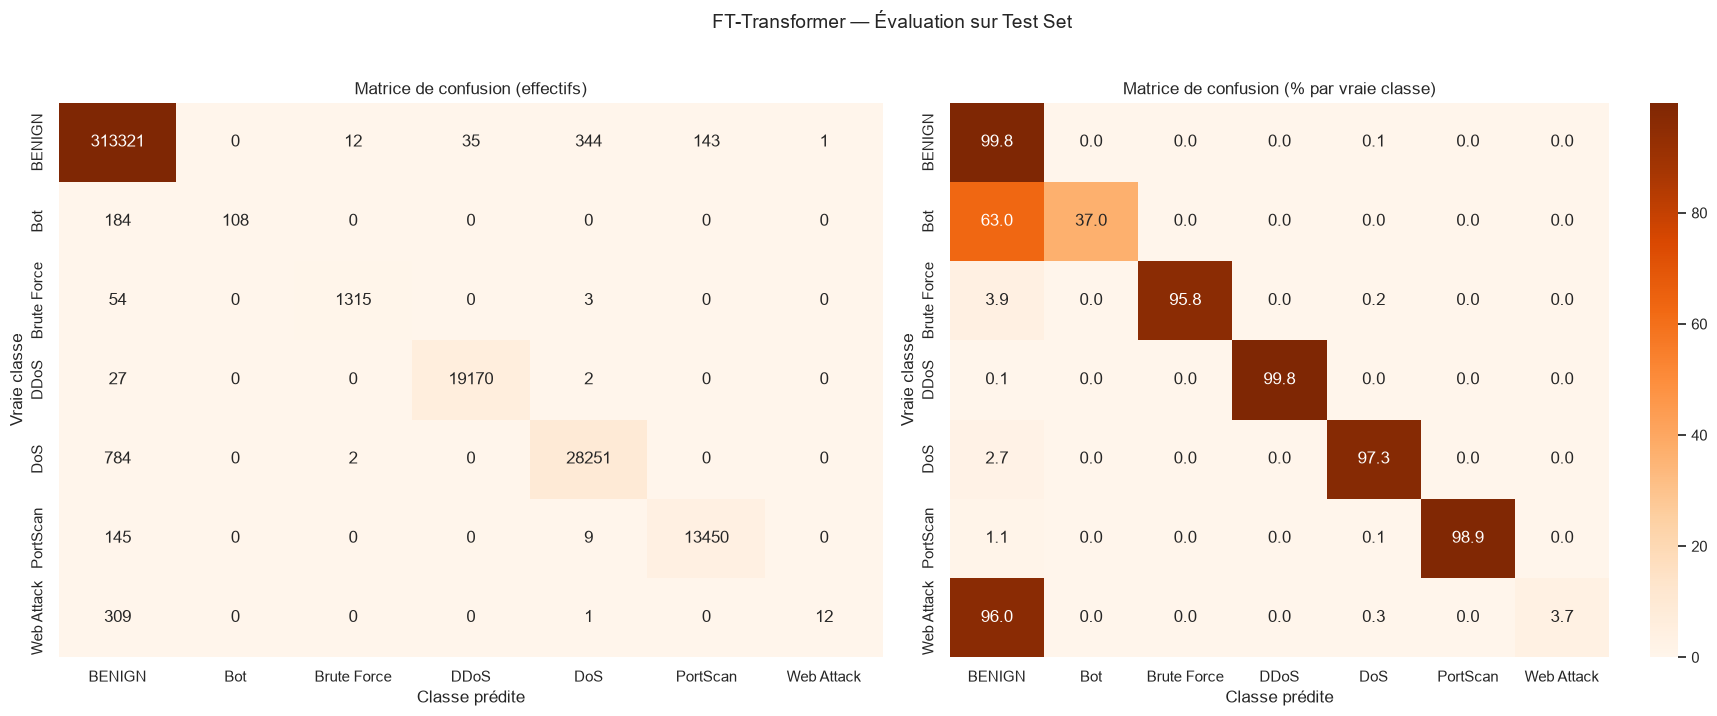

In [11]:
cm = confusion_matrix(y_test_true, y_test_pred_ft)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Oranges',
    xticklabels=class_names, yticklabels=class_names,
    ax=axes[0], cbar=False,
)
axes[0].set_title('Matrice de confusion (effectifs)')
axes[0].set_xlabel('Classe prédite')
axes[0].set_ylabel('Vraie classe')

sns.heatmap(
    cm_norm, annot=True, fmt='.1f', cmap='Oranges',
    xticklabels=class_names, yticklabels=class_names,
    ax=axes[1], cbar=True,
)
axes[1].set_title('Matrice de confusion (% par vraie classe)')
axes[1].set_xlabel('Classe prédite')
axes[1].set_ylabel('Vraie classe')

plt.suptitle('FT-Transformer — Évaluation sur Test Set', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_FIGURES / '07_ft_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Comparaison finale des 4 modèles

**Le moment de vérité : le grand match RF / XGBoost / DNN / FT-Transformer.**

In [15]:
# Recharger tous les rapports
with open(RESULTS_METRICS / 'rf_test_report.json') as f:
    rf_report = json.load(f)
with open(RESULTS_METRICS / 'xgb_test_report.json') as f:
    xgb_report = json.load(f)
with open(RESULTS_METRICS / 'dnn_test_report.json') as f:
    dnn_report = json.load(f)

# Tableau récap
summary = pd.DataFrame([
    {
        'Modèle': 'Random Forest',
        'Accuracy': rf_report['accuracy'],
        'F1 macro': rf_report['macro avg']['f1-score'],
        'F1 pondéré': rf_report['weighted avg']['f1-score'],
    },
    {
        'Modèle': 'XGBoost (Optuna)',
        'Accuracy': xgb_report['accuracy'],
        'F1 macro': xgb_report['macro avg']['f1-score'],
        'F1 pondéré': xgb_report['weighted avg']['f1-score'],
    },
    {
        'Modèle': 'DNN (PyTorch)',
        'Accuracy': dnn_report['accuracy'],
        'F1 macro': dnn_report['macro avg']['f1-score'],
        'F1 pondéré': dnn_report['weighted avg']['f1-score'],
    },
    {
        'Modèle': 'FT-Transformer',
        'Accuracy': ft_acc,
        'F1 macro': ft_f1_macro,
        'F1 pondéré': ft_f1_weighted,
    },
])
summary_display = summary.set_index('Modèle').round(4)
print('='*70)
print('  COMPARAISON FINALE — 4 MODÈLES sur Test Set')
print('='*70)
print(summary_display)
print('='*70)

summary.to_csv(RESULTS_METRICS / 'phase_bc_final_summary.csv', index=False)

  COMPARAISON FINALE — 4 MODÈLES sur Test Set
                  Accuracy  F1 macro  F1 pondéré
Modèle                                          
Random Forest       0.9962    0.8997      0.9971
XGBoost (Optuna)    0.9990    0.9689      0.9991
DNN (PyTorch)       0.9621    0.7253      0.9715
FT-Transformer      0.9946    0.7928      0.9941


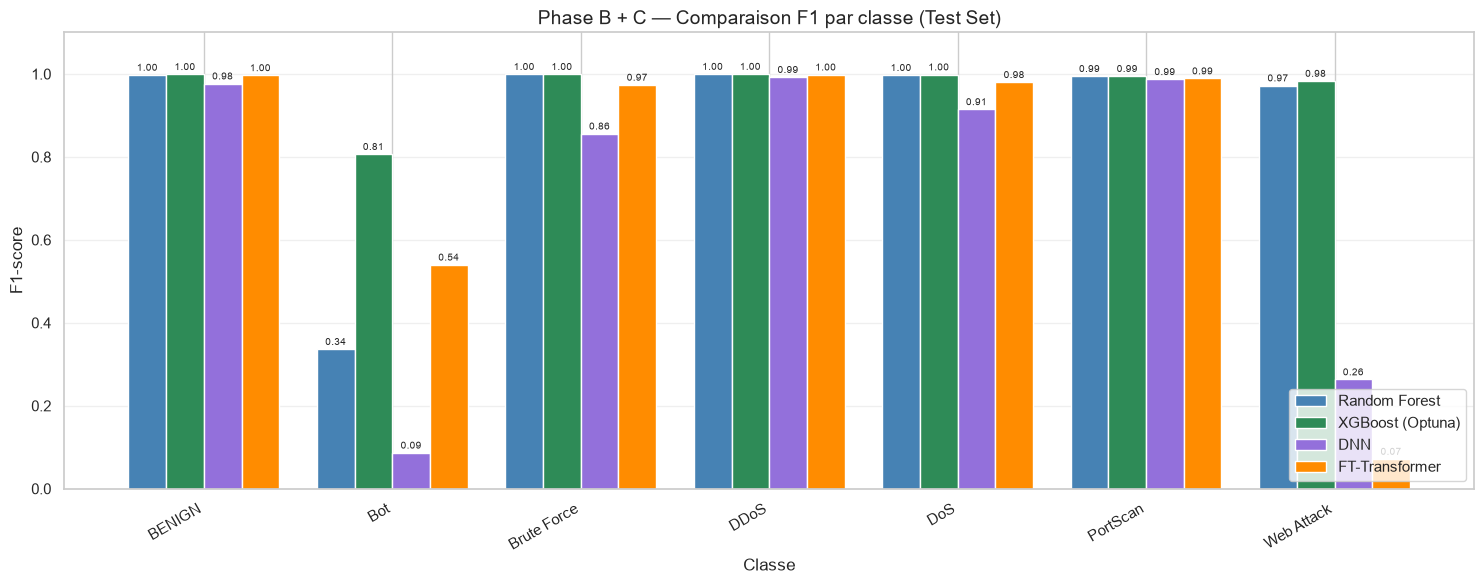

In [16]:
# Graphique F1 par classe pour les 4 modèles
rf_f1s = [rf_report[cls]['f1-score'] for cls in class_names]
xgb_f1s = [xgb_report[cls]['f1-score'] for cls in class_names]
dnn_f1s = [dnn_report[cls]['f1-score'] for cls in class_names]
ft_f1s = [ft_test_report_dict[cls]['f1-score'] for cls in class_names]

fig, ax = plt.subplots(figsize=(15, 6))
x = np.arange(len(class_names))
width = 0.20

ax.bar(x - 1.5*width, rf_f1s, width, label='Random Forest', color='steelblue')
ax.bar(x - 0.5*width, xgb_f1s, width, label='XGBoost (Optuna)', color='seagreen')
ax.bar(x + 0.5*width, dnn_f1s, width, label='DNN', color='mediumpurple')
ax.bar(x + 1.5*width, ft_f1s, width, label='FT-Transformer', color='darkorange')

ax.set_xlabel('Classe')
ax.set_ylabel('F1-score')
ax.set_title('Phase B + C — Comparaison F1 par classe (Test Set)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=30, ha='right')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 1.1)

for i, (rf_v, xgb_v, dnn_v, ft_v) in enumerate(zip(rf_f1s, xgb_f1s, dnn_f1s, ft_f1s)):
    ax.text(i - 1.5*width, rf_v + 0.01, f'{rf_v:.2f}', ha='center', fontsize=7)
    ax.text(i - 0.5*width, xgb_v + 0.01, f'{xgb_v:.2f}', ha='center', fontsize=7)
    ax.text(i + 0.5*width, dnn_v + 0.01, f'{dnn_v:.2f}', ha='center', fontsize=7)
    ax.text(i + 1.5*width, ft_v + 0.01, f'{ft_v:.2f}', ha='center', fontsize=7)

plt.tight_layout()
plt.savefig(RESULTS_FIGURES / '07_four_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

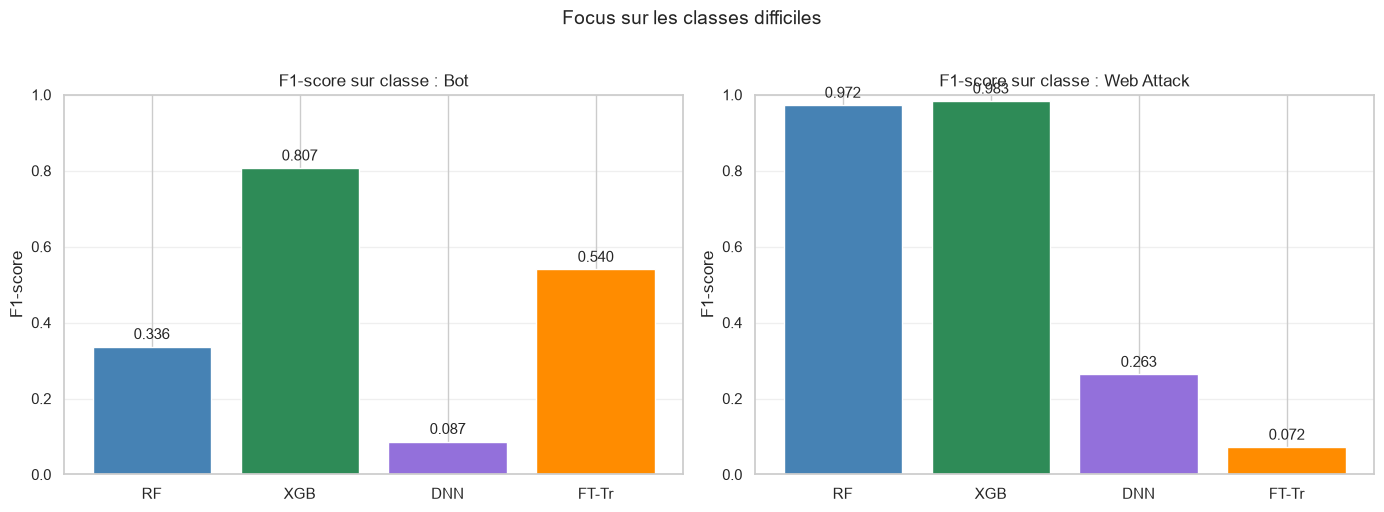

In [17]:
# Graphique focalisé sur les classes difficiles (Bot, Web Attack)
difficult_classes = ['Bot', 'Web Attack']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, cls in zip(axes, difficult_classes):
    values = [
        rf_report[cls]['f1-score'],
        xgb_report[cls]['f1-score'],
        dnn_report[cls]['f1-score'],
        ft_test_report_dict[cls]['f1-score'],
    ]
    labels = ['RF', 'XGB', 'DNN', 'FT-Tr']
    colors = ['steelblue', 'seagreen', 'mediumpurple', 'darkorange']
    bars = ax.bar(labels, values, color=colors)
    ax.set_ylim(0, 1.0)
    ax.set_title(f'F1-score sur classe : {cls}', fontsize=12)
    ax.set_ylabel('F1-score')
    ax.grid(True, alpha=0.3, axis='y')
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.02, f'{v:.3f}', ha='center', fontsize=11)

plt.suptitle('Focus sur les classes difficiles', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_FIGURES / '07_difficult_classes_focus.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Sauvegarde

In [18]:
# Sauvegarde via la méthode pytorch-tabular
ft_model_dir = RESULTS_MODELS / 'ft_transformer'
tabular_model.save_model(str(ft_model_dir))
print(f'✅ Modèle FT-Transformer sauvegardé : {ft_model_dir}')
print(f'\nTaille du dossier modèle :')
import os
total_size = 0
for dirpath, _, filenames in os.walk(ft_model_dir):
    for f in filenames:
        fp = os.path.join(dirpath, f)
        total_size += os.path.getsize(fp)
print(f'   {total_size / 1024**2:.1f} MB')

`weights_only` was not set, defaulting to `False`.


✅ Modèle FT-Transformer sauvegardé : ..\results\models\ft_transformer

Taille du dossier modèle :
   1767.2 MB


## 🎉 Récapitulatif

Tu viens d'entraîner l'architecture deep learning state-of-the-art pour données tabulaires (FT-Transformer, 2021) sur ton problème de cybersécurité.

**Fichiers produits :**
- `results/models/ft_transformer/` : dossier du modèle
- `results/metrics/ft_test_report.json` : métriques détaillées
- `results/metrics/phase_bc_final_summary.csv` : tableau récap final des 4 modèles
- `results/figures/07_ft_confusion_matrix.png`
- `results/figures/07_four_models_comparison.png`
- `results/figures/07_difficult_classes_focus.png`

### Prochaine étape

**Phase D — XAI** : le cœur original de ton projet. On va appliquer SHAP et LIME sur ton meilleur modèle (probablement XGBoost vu les résultats) pour produire des explications utilisables par un analyste SOC.

C'est là que ton mémoire va vraiment se différencier des autres PFE.